# Árboles de decisión: clasificación y regresión

> Cómo un árbol parte los datos con preguntas del tipo «¿$x_j \le t$?» hasta formar regiones casi puras, cómo se elige cada corte (Gini, entropía), por qué sobreajusta si se deja crecer y cómo se poda. Y sus límites: inestabilidad, importancias engañosas y ninguna extrapolación.
>
> **Requisitos previos:** [Flujo de ML y evaluación](01-flujo-ml-y-evaluacion.ipynb) · **Relacionado:** [k-NN](07-knn.ipynb) · [selección de atributos](03-seleccion-atributos.ipynb) · [bagging y Random Forest](10-bagging-y-random-forest.ipynb)

## 1. Idea clave

Un **árbol de decisión** predice encadenando preguntas sobre una sola variable cada vez («¿el radio es menor que 16,8?»). Cada pregunta divide los datos en dos grupos, y se repite en cada grupo hasta llegar a una **hoja**, que da la predicción: la clase mayoritaria (clasificación) o la media (regresión) de los ejemplos que llegan a ella. El resultado es un conjunto de reglas `si… entonces…` que cualquiera puede leer.

Es una de las pocas técnicas **interpretables**, no necesita escalar los datos, maneja relaciones no lineales e interacciones entre variables y es muy rápido de predecir. A cambio, un árbol sin límites **memoriza** los datos de entrenamiento, es **inestable** (un cambio pequeño en los datos puede dar un árbol distinto) y **no extrapola**. Esas debilidades son el motivo de que casi siempre se combinen muchos árboles ([bagging](10-bagging-y-random-forest.ipynb) y [boosting](11-boosting.ipynb)).

## 2. Conceptos importantes

### 2.1. Estructura y predicción

Un árbol binario tiene **nodos internos** (cada uno con una condición $x_j \le t$ sobre una variable $x_j$ y un umbral $t$) y **hojas**. Cada condición divide el espacio con un hiperplano **paralelo a un eje**, así que el árbol parte el espacio en **rectángulos** (cajas), y la predicción es constante dentro de cada uno. La **profundidad** es el mayor número de condiciones que hay que cruzar hasta una hoja.

### 2.2. Medir la impureza y elegir el corte

Un nodo es **puro** si todos sus ejemplos son de la misma clase. Para decidir qué corte es mejor se mide la **impureza** $I$ del nodo a partir de las proporciones $p_c$ de cada clase $c$ en él:

$$
\text{Gini} = \sum_{c} p_c\,(1 - p_c) = 1 - \sum_{c} p_c^{2}
\qquad\qquad
\text{Entropía} = -\sum_{c} p_c \log_2 p_c
$$

Ambas valen 0 en un nodo puro y son máximas cuando las clases están a partes iguales (con dos clases, Gini = 0,5 y entropía = 1). Un corte divide un nodo de $n$ ejemplos en un hijo izquierdo ($n_I$ ejemplos) y uno derecho ($n_D$). Se prefiere el corte con mayor **reducción de impureza**:

$$
\Delta I = I(\text{nodo}) - \frac{n_I}{n}\, I(\text{izq}) - \frac{n_D}{n}\, I(\text{der})
$$

En **regresión**, la impureza es la varianza de $y$ en el nodo, $I = \frac{1}{n}\sum_i (y_i - \bar{y})^2$ (el error cuadrático medio de predecir la media), y la hoja predice $\bar{y}$.

### 2.3. Cómo crece: un algoritmo voraz

Para cada variable numérica se ordenan los valores y se prueban como umbral los puntos medios entre valores consecutivos; se queda el corte con mayor $\Delta I$ entre todas las variables. Luego se repite **recursivamente** en cada hijo hasta que se cumple un criterio de parada (profundidad máxima, pocos ejemplos, nodo puro…). Es un algoritmo **voraz** (*greedy*): elige lo mejor en cada paso, sin mirar adelante, por lo que no garantiza el árbol óptimo global.

### 2.4. Sobreajuste y poda

Si no se pone ningún límite, el árbol sigue dividiendo hasta que todas las hojas son puras: **clasifica perfectamente el entrenamiento**, memorizando incluso el ruido, y generaliza peor. Hay dos maneras de frenarlo:

- **Prepoda**: limitar el crecimiento (`max_depth`, `min_samples_split`, `min_samples_leaf`, `max_leaf_nodes`, `min_impurity_decrease`).
- **Pospoda por coste-complejidad**: crecer el árbol completo y recortarlo después, minimizando

$$
R_\alpha(T) = R(T) + \alpha\,|T|
$$

  donde $R(T)$ es la impureza total de las hojas del árbol $T$, $|T|$ su número de hojas y $\alpha \ge 0$ el precio de cada hoja. Con $\alpha = 0$ no se poda nada, y al subir $\alpha$ se eliminan primero las ramas que menos reducen la impureza. En scikit-learn es `ccp_alpha`, y se elige con validación cruzada.

### 2.5. Propiedades

- **Invariantes al escalado** y a cualquier transformación monótona de una variable: solo importa el orden de los valores, no su magnitud.
- **Interpretables**: se pueden leer como reglas.
- **Inestables** (alta varianza): al cambiar un poco los datos, puede cambiar la variable de la raíz y todo lo que cuelga de ella.
- **Constantes a trozos**: la predicción es un "escalón" por región, así que no extrapolan fuera del rango de entrenamiento.

### 2.6. Importancia de las variables

`feature_importances_` suma, para cada variable, la reducción de impureza que aportan sus cortes (en entrenamiento). Es rápida, pero tiene un sesgo: **favorece a las variables continuas o con muchos valores distintos**, que ofrecen más umbrales entre los que encontrar un corte favorable por azar. Alternativa más fiable: la **importancia por permutación**, que mide cuánto empeora el error en test al barajar una variable.

## 3. Código

Usamos **breast cancer** (569 tumores, 30 medidas numéricas, clase benigno/maligno; `load_breast_cancer`, derivado del repositorio UCI) para clasificar, unas **lunas** con ruido para ver las regiones, y datos **sintéticos** para la regresión y las importancias, donde conocemos la verdad.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, make_classification, make_moons
from sklearn.inspection import DecisionBoundaryDisplay, permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

### 3.1. Un árbol sin límites

Separamos un 20 % para el test (clase 0 = maligno, 1 = benigno) y dejamos crecer un árbol sin restricciones.

In [2]:
X, y = load_breast_cancer(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

arbol = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
print(f"Exactitud en entrenamiento: {arbol.score(X_train, y_train):.3f}")
print(f"Exactitud en test:          {arbol.score(X_test, y_test):.3f}")
print(f"Profundidad: {arbol.get_depth()} | hojas: {arbol.get_n_leaves()}")

Exactitud en entrenamiento: 1.000
Exactitud en test:          0.912
Profundidad: 7 | hojas: 19


El árbol acierta el **100 %** del entrenamiento (memorizado) y baja en test. Comprobamos a mano la impureza de Gini de la raíz con la fórmula de la sección 2.2:

In [3]:
p = y_train.value_counts(normalize=True)
print(f"Gini de la raíz, a mano:  {1 - (p ** 2).sum():.4f}")
print(f"Gini de la raíz, del árbol: {arbol.tree_.impurity[0]:.4f}")

Gini de la raíz, a mano:  0.4681
Gini de la raíz, del árbol: 0.4681


### 3.2. Leer el árbol

Un árbol de profundidad 3 es lo bastante pequeño para leerlo. Cada nodo muestra la condición (se va a la izquierda si es cierta), su impureza (`gini`), el nº de ejemplos (`samples`) y cómo se reparten (`value`: [malignos, benignos]); el color indica la clase mayoritaria (naranja, maligno; azul, benigno).

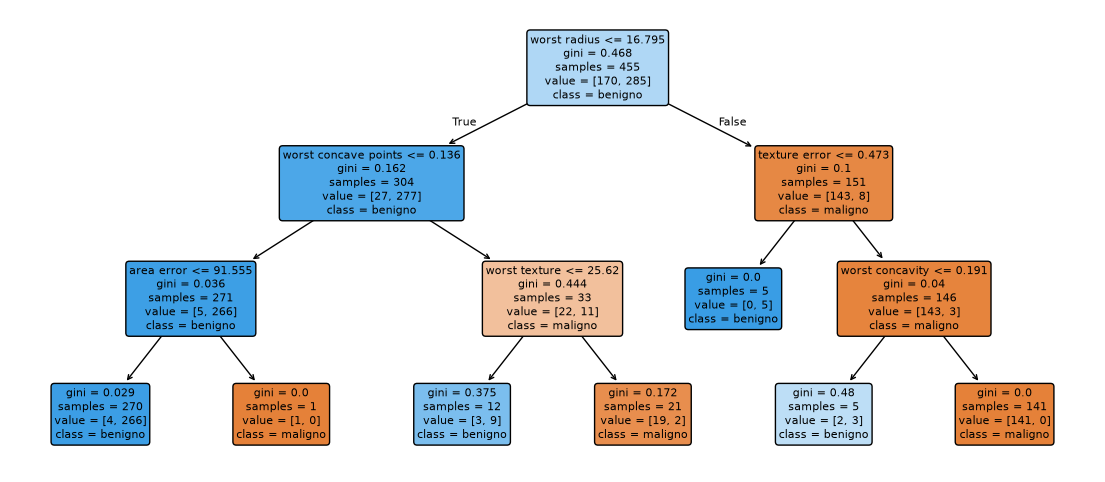

Exactitud en test: 0.939


In [4]:
arbol_corto = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)

plt.figure(figsize=(14, 6))
plot_tree(arbol_corto, feature_names=list(X.columns), class_names=["maligno", "benigno"],
          filled=True, rounded=True, fontsize=8)
plt.show()
print(f"Exactitud en test: {arbol_corto.score(X_test, y_test):.3f}")

La raíz pregunta por `worst radius`. Si es mayor que 16,8, casi todos son malignos (143 de 151) y basta una pregunta más para afinar. Si es menor, casi todos son benignos (277 de 304), y el árbol necesita más condiciones para pescar los malignos restantes. Con solo 7 hojas, el árbol acierta el 94 % del test, y cada decisión se puede explicar con 3 condiciones.

### 3.3. Controlar la complejidad

Primero, la **prepoda**: exactitud en entrenamiento y en validación cruzada según `max_depth`.

In [5]:
filas = []
for profundidad in [1, 2, 3, 4, 5, 6, 8, 10, None]:
    modelo = DecisionTreeClassifier(max_depth=profundidad, random_state=42)
    puntuaciones = cross_val_score(modelo, X_train, y_train, cv=cv)
    filas.append({"max_depth": "sin límite" if profundidad is None else profundidad, "entrenamiento": modelo.fit(X_train, y_train).score(X_train, y_train),
                  "CV media": puntuaciones.mean(), "CV std": puntuaciones.std()})
pd.DataFrame(filas).set_index("max_depth").round(3)

,entrenamiento,CV media,CV std
max_depth,,,
1,0.923,0.903,0.008
2,0.958,0.932,0.019
3,0.976,0.925,0.008
4,0.987,0.930,0.015
5,0.993,0.923,0.012
6,0.998,0.925,0.013
8,1.000,0.923,0.012
10,1.000,0.916,0.018
sin límite,1.000,0.916,0.018


Con profundidad 1 (un solo corte) el árbol se queda corto (subajuste). Entre 2 y 6 la validación cruzada se mueve en una banda estrecha (0,92–0,93), y a partir de 8 el árbol llega al 100 % en entrenamiento mientras la validación cruzada baja ligeramente (de 0,923 a 0,916 sin límite): sobreajuste. Las diferencias entre profundidades vecinas son del orden de la desviación entre particiones (≈ 0,01–0,02).

Ahora la **pospoda**: `cost_complexity_pruning_path` calcula los valores de $\alpha$ en los que el árbol completo pierde una rama, y se evalúa cada uno con validación cruzada.

In [6]:
camino = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
alfas = camino.ccp_alphas[:-1]  # el último valor deja solo la raíz

filas = []
for alfa in alfas:
    modelo = DecisionTreeClassifier(ccp_alpha=alfa, random_state=42)
    filas.append({"alfa": alfa, "hojas": modelo.fit(X_train, y_train).get_n_leaves(),
                  "CV media": cross_val_score(modelo, X_train, y_train, cv=cv).mean()})
poda = pd.DataFrame(filas)
mejor_alfa = poda.loc[poda["CV media"].idxmax(), "alfa"]

podado = DecisionTreeClassifier(ccp_alpha=mejor_alfa, random_state=42).fit(X_train, y_train)
print(f"Mejor alfa por validación cruzada: {mejor_alfa:.4f}")
pd.DataFrame.from_dict({
    "árbol completo": {"hojas": arbol.get_n_leaves(), "profundidad": arbol.get_depth(),
                       "CV media": poda["CV media"].iloc[0], "test": arbol.score(X_test, y_test)},
    "árbol podado": {"hojas": podado.get_n_leaves(), "profundidad": podado.get_depth(),
                     "CV media": poda["CV media"].max(), "test": podado.score(X_test, y_test)},
}, orient="index").round(3)

Mejor alfa por validación cruzada: 0.0053


,hojas,profundidad,CV media,test
árbol completo,19,7,0.916,0.912
árbol podado,7,4,0.932,0.930


La poda reduce el árbol de 19 a 7 hojas y mejora la validación cruzada en ≈ 1,5 puntos (de 0,916 a 0,932). En test sube de 0,912 a 0,930, pero con 114 casos eso son 2 aciertos más: **no es una mejora demostrada**. Lo que sí está claro es que un árbol casi tres veces más pequeño rinde igual o algo mejor y se puede leer entero.

### 3.4. Inestabilidad

Entrenamos el mismo árbol (profundidad 3) con 8 particiones distintas entrenamiento/test y miramos la pregunta de la raíz:

In [7]:
filas = []
for semilla in range(8):
    a_train, a_test, b_train, b_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=semilla)
    t = DecisionTreeClassifier(max_depth=3, random_state=42).fit(a_train, b_train)
    filas.append({"partición": semilla, "variable de la raíz": X.columns[t.tree_.feature[0]],
                  "umbral": t.tree_.threshold[0], "exactitud test": t.score(a_test, b_test)})
pd.DataFrame(filas).set_index("partición").round(3)

,variable de la raíz,umbral,exactitud test
partición,,,
0,worst concave points,0.142,0.921
1,worst radius,16.795,0.947
2,worst radius,16.795,0.947
3,worst concave points,0.147,0.939
4,worst perimeter,111.500,0.921
5,worst perimeter,111.500,0.921
6,worst radius,16.805,0.974
7,worst perimeter,105.950,0.930


La raíz cambia entre `worst radius`, `worst perimeter` y `worst concave points` (variables muy correlacionadas entre sí, así que casi equivalentes) y los umbrales varían, y la exactitud en test oscila entre ≈ 0,92 y ≈ 0,97. Un árbol es una **fotografía** de los datos con los que se entrenó: de ahí que se promedien muchos en un [bosque](10-bagging-y-random-forest.ipynb).

### 3.5. Las regiones: rectángulos

En 2D se ve cómo parte el espacio. Lunas con mucho ruido, un árbol sin límites y otro con `max_depth=4`:

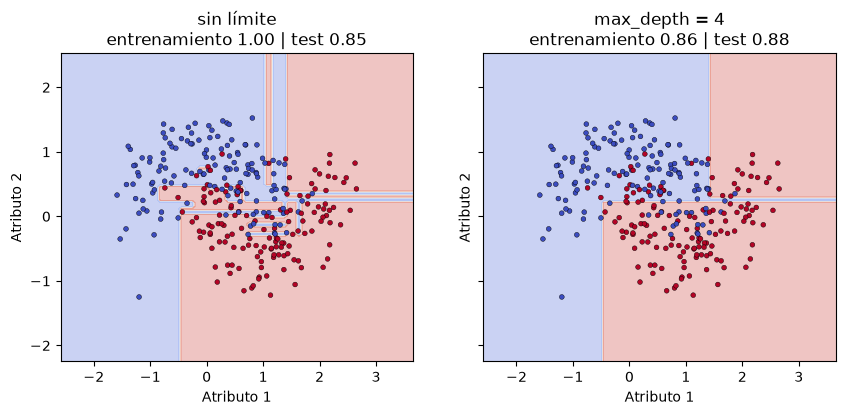

In [8]:
X_lunas, y_lunas = make_moons(n_samples=400, noise=0.35, random_state=42)
Xl_train, Xl_test, yl_train, yl_test = train_test_split(X_lunas, y_lunas, test_size=0.3,
                                                         stratify=y_lunas, random_state=42)

fig, ejes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for eje, profundidad in zip(ejes, [None, 4]):
    t = DecisionTreeClassifier(max_depth=profundidad, random_state=42).fit(Xl_train, yl_train)
    DecisionBoundaryDisplay.from_estimator(t, Xl_train, response_method="predict", cmap="coolwarm",
                                           alpha=0.3, ax=eje, xlabel="Atributo 1", ylabel="Atributo 2")
    eje.scatter(*Xl_train.T, c=yl_train, cmap="coolwarm", s=12, edgecolor="k", linewidth=0.3)
    nombre = "sin límite" if profundidad is None else f"max_depth = {profundidad}"
    eje.set_title(f"{nombre}\nentrenamiento {t.score(Xl_train, yl_train):.2f} | test {t.score(Xl_test, yl_test):.2f}")
plt.show()

Las fronteras son siempre **rectangulares** (cortes paralelos a los ejes). El árbol sin límite rodea los puntos ruidosos con franjas y cajas muy estrechas y llega al 100 % en entrenamiento; con `max_depth=4` las regiones son pocas y amplias.

### 3.6. Regresión y extrapolación

Una relación lineal con algo de ruido, $y = 3x + 500$. Entrenamos con $x < 6$ y evaluamos con $x \ge 6$, fuera del rango visto, y comparamos un árbol de regresión con una regresión lineal:

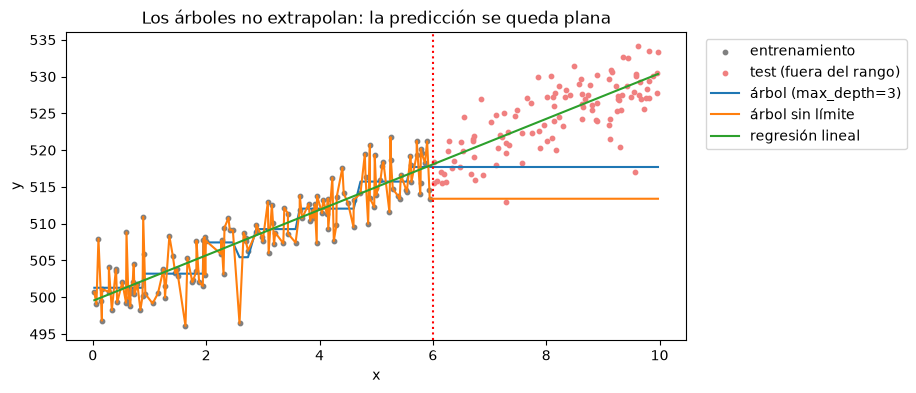

,R² entrenamiento,R² test
árbol (max_depth=3),0.807,-2.103
árbol sin límite,1.000,-5.589
regresión lineal,0.782,0.564


In [9]:
rng = np.random.default_rng(0)
x = np.sort(rng.uniform(0, 10, 250))
y_lin = 3 * x + 500 + rng.normal(0, 3, 250)
visto = x < 6
x_tr, y_tr, x_te, y_te = x[visto], y_lin[visto], x[~visto], y_lin[~visto]

modelos = {
    "árbol (max_depth=3)": DecisionTreeRegressor(max_depth=3, random_state=0),
    "árbol sin límite": DecisionTreeRegressor(random_state=0),
    "regresión lineal": LinearRegression(),
}
plt.figure(figsize=(8, 4))
plt.scatter(x_tr, y_tr, s=10, color="gray", label="entrenamiento")
plt.scatter(x_te, y_te, s=10, color="lightcoral", label="test (fuera del rango)")
resultados = {}
for nombre, modelo in modelos.items():
    modelo.fit(x_tr.reshape(-1, 1), y_tr)
    plt.plot(x, modelo.predict(x.reshape(-1, 1)), label=nombre)
    resultados[nombre] = {"R² entrenamiento": r2_score(y_tr, modelo.predict(x_tr.reshape(-1, 1))),
                          "R² test": r2_score(y_te, modelo.predict(x_te.reshape(-1, 1)))}
plt.axvline(6, color="red", linestyle=":")
plt.title("Los árboles no extrapolan: la predicción se queda plana")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.show()
pd.DataFrame(resultados).T.round(3)

El árbol aproxima la recta con **escalones** y, pasada la línea roja, repite el último valor que vio. Su R² en test es **negativo**: peor que predecir siempre la media de $y$. El árbol sin límite llega a $R^2 = 1$ en entrenamiento, y es incluso peor fuera. La regresión lineal, que tiene la forma funcional correcta, sí extrapola. Si los datos futuros pueden salirse del rango de entrenamiento, un árbol no es la herramienta; y la misma limitación afecta a [k-NN](07-knn.ipynb) y a los bosques de árboles.

### 3.7. Importancia de las variables: impureza frente a permutación

Dos variables útiles y tres de puro ruido (una binaria, una continua y un identificador aleatorio con muchos valores). Entrenamos un árbol sin límites y comparamos las dos importancias; la de permutación se calcula en test.

In [10]:
X_sint, y_sint = make_classification(n_samples=600, n_features=2, n_informative=2, n_redundant=0,
                                     n_clusters_per_class=1, flip_y=0.1, random_state=42)
X_sint = pd.DataFrame(X_sint, columns=["util_1", "util_2"])
rng = np.random.default_rng(42)
X_sint["ruido_binario"] = rng.integers(0, 2, len(X_sint))
X_sint["ruido_continuo"] = rng.normal(size=len(X_sint))
X_sint["id_aleatorio"] = rng.integers(0, 600, len(X_sint))

Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_sint, y_sint, test_size=0.3, stratify=y_sint, random_state=42)
arbol_sint = DecisionTreeClassifier(random_state=42).fit(Xs_train, ys_train)
perm = permutation_importance(arbol_sint, Xs_test, ys_test, n_repeats=30, random_state=42)

print(f"Exactitud: entrenamiento {arbol_sint.score(Xs_train, ys_train):.2f} | test {arbol_sint.score(Xs_test, ys_test):.2f}")
pd.DataFrame({"importancia por impureza": arbol_sint.feature_importances_,
              "importancia por permutación (test)": perm.importances_mean}, index=X_sint.columns).round(3)

Exactitud: entrenamiento 1.00 | test 0.82


,importancia por impureza,importancia por permutación (test)
util_1,0.178,0.075
util_2,0.638,0.286
ruido_binario,0.021,-0.006
ruido_continuo,0.047,0.005
id_aleatorio,0.117,-0.002


La importancia por impureza reparte ≈ 18 % entre las variables de ruido, sobre todo en el identificador (0,12), que tiene muchos valores distintos y por tanto muchos umbrales con los que el árbol memoriza el entrenamiento. La importancia por permutación, calculada en test, deja el ruido en ≈ 0 e identifica sin ambigüedad las dos variables útiles. (Más sobre importancias en [selección de atributos](03-seleccion-atributos.ipynb).)

## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros que conviene conocer

| Parámetro | Qué controla | Consejo |
|---|---|---|
| `criterion` | Medida de impureza: `"gini"` (por defecto), `"entropy"`, `"log_loss"` (clasificación); `"squared_error"` y otros (regresión) | Casi no cambia el resultado; Gini es algo más rápido |
| `max_depth` | Profundidad máxima | Principal freno al sobreajuste; pruébalo en un rango amplio |
| `min_samples_split` | Ejemplos mínimos que debe tener un **nodo** para poder dividirse | No garantiza el tamaño de las hojas (ver error 5) |
| `min_samples_leaf` | Ejemplos mínimos que debe tener **cada hoja** resultante | Suaviza el modelo, sobre todo en regresión |
| `max_leaf_nodes` | Nº máximo de hojas | Alternativa a `max_depth` que crece por el nodo más útil |
| `min_impurity_decrease` | Reducción mínima de impureza para dividir | Evita cortes que apenas mejoran |
| `ccp_alpha` | Poda por coste-complejidad ($\alpha$ de la sección 2.4) | Se elige con `cost_complexity_pruning_path` y validación cruzada |
| `max_features` | Variables que se consideran en cada corte | Todas por defecto; limitarlas es la base de los [bosques](10-bagging-y-random-forest.ipynb) |
| `class_weight` | Peso por clase | `"balanced"` con clases desbalanceadas |
| `random_state` | Semilla (los empates entre cortes se resuelven al azar) | Fíjala para reproducir resultados |

### 4.2. Errores comunes

**1. Dejar el árbol crecer sin límites.** Acierta el 100 % del entrenamiento y falla fuera: en la sección 3.1 pasa de 1,00 a 0,91. En un problema real con muchas variables irrelevantes, el hueco fue mucho mayor (de ≈ 1,00 a ≈ 0,67). Evalúa siempre con un conjunto que el árbol no haya visto y limita el crecimiento (profundidad, hoja mínima o poda).

**2. Una rejilla de búsqueda demasiado estrecha.** Si los valores de `max_depth` probados son, por ejemplo, de 4 a 9 y el mejor sale en el **extremo** (9), no sabes si el óptimo está más allá: amplía el rango hasta ver la curva subir y bajar, como en 3.3. Y cuidado al comparar con el árbol sin límites: con un test pequeño, la diferencia puede ser ruido. Un árbol podado puede quedar *por debajo* del completo en test sin que importe. Cuando escribas los resultados, cópialos de la salida (en un caso, el texto decía una profundidad óptima de 20 y la búsqueda había dado 9).

**3. Esperar que extrapole.** En 3.6, el árbol sin límite tiene $R^2 = 1{,}000$ en entrenamiento y $-5{,}6$ fuera del rango. Para tendencias, usa un modelo con forma funcional (regresión), o transforma el problema para que los datos nuevos caigan dentro del rango visto.

**4. Fiarse de `feature_importances_`.** Es una medida de entrenamiento y favorece a las variables con muchos valores (3.7). Contrasta con la importancia por permutación en test, y recuerda que con variables correlacionadas la importancia se reparte de forma arbitraria entre ellas (3.4).

**5. Confundir `min_samples_split` con `min_samples_leaf`.** El primero es el mínimo para **dividir un nodo**, no el tamaño mínimo de una hoja: un nodo de 21 ejemplos puede dividirse en una hoja de 20 y otra de 1. Lo comprobamos:

In [11]:
for parametro in ["min_samples_split", "min_samples_leaf"]:
    t = DecisionTreeClassifier(random_state=42, **{parametro: 20}).fit(X_train, y_train)
    es_hoja = t.tree_.children_left == -1
    print(f"{parametro}=20 -> hoja más pequeña: {t.tree_.n_node_samples[es_hoja].min()} ejemplo(s)")

min_samples_split=20 -> hoja más pequeña: 1 ejemplo(s)
min_samples_leaf=20 -> hoja más pequeña: 20 ejemplo(s)


Con `min_samples_split=20` aparecen hojas de **1** ejemplo; con `min_samples_leaf=20`, ninguna hoja baja de 20.

**6. One-hot con categorías de alta cardinalidad.** Un `get_dummies` sobre variables como "empresa" o "desarrollador" produce miles de columnas casi vacías (en un caso, casi 4.000): el árbol puede usarlas para aislar casos concretos y sobreajustar, y su importancia queda diluida entre columnas. Agrupa las categorías raras, usa una codificación más compacta y fija `min_samples_leaf`. (scikit-learn no admite variables categóricas nativas en `DecisionTreeClassifier`.)

**7. Escalar "por si acaso".** Los árboles son invariantes al escalado: estandarizar no cambia nada, solo añade un paso.

In [12]:
con_escala = make_pipeline(StandardScaler(), DecisionTreeClassifier(random_state=42)).fit(X_train, y_train)
print(f"Exactitud en test sin escalar: {arbol.score(X_test, y_test):.3f} | estandarizando: {con_escala.score(X_test, y_test):.3f}")

Exactitud en test sin escalar: 0.912 | estandarizando: 0.912


(El escalado sí importa en [k-NN](07-knn.ipynb) o [SVM](09-svm.ipynb); aquí es solo ruido.)

**8. Quedarse con la exactitud con clases desbalanceadas.** Si una clase es rara, un árbol puede acertar casi siempre prediciendo la mayoritaria. Mira la matriz de confusión y una métrica que corresponda al problema (sensibilidad de la clase rara, $F_1$), y usa `class_weight="balanced"` o [remuestrea](../03-preparacion-datos/04-muestreo-y-desbalanceo.ipynb).

## 5. Comparación con métodos relacionados

| Método | Interpretabilidad | Varianza | ¿Escalar? | No linealidad e interacciones | Extrapola | Cuándo usarlo |
|---|---|---|---|---|---|---|
| **Árbol de decisión** | Alta (reglas) | Alta (inestable) | No | Sí, automáticas | No | Cuando hay que explicar con reglas; línea base no lineal rápida |
| [k-NN](07-knn.ipynb) | Por ejemplos | Media (según $k$) | Sí | Sí | No | Pocas variables bien escaladas; línea base sin entrenamiento |
| Regresión logística / lineal | Alta (coeficientes) | Baja | Recomendable | No (hay que añadirlas) | Sí | Relaciones aproximadamente lineales; tendencias |
| [SVM con núcleo](09-svm.ipynb) | Baja | Baja–media | Sí | Sí (según el núcleo) | Según el núcleo | Datos de tamaño medio con fronteras curvas |
| [Random Forest](10-bagging-y-random-forest.ipynb) | Media (importancias) | Baja | No | Sí | No | Primera opción tabular: promedia muchos árboles |
| [Gradient Boosting](11-boosting.ipynb) | Media | Baja–media | No | Sí | No | Máxima precisión tabular, con más ajuste |

**Cuándo elegir un árbol solo.** Cuando el modelo tiene que ser **explicable** como conjunto de reglas (decisiones auditables, protocolos médicos o de negocio), como línea base no lineal sin preparación de datos, o como pieza de un bosque. Si lo único que importa es la precisión, casi siempre rinde más un conjunto de árboles ([bagging](10-bagging-y-random-forest.ipynb), [boosting](11-boosting.ipynb)) que uno solo.

## 6. Referencias

### Fuentes

- scikit-learn: [*Decision Trees*](https://scikit-learn.org/stable/modules/tree.html) (criterios, poda por coste-complejidad, valores perdidos, limitaciones), [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html), [`DecisionTreeRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html) y [`plot_tree`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html).
- scikit-learn: [*Permutation feature importance*](https://scikit-learn.org/stable/modules/permutation_importance.html) y [`permutation_importance`](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html).
- scikit-learn: dataset [`load_breast_cancer`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) y generadores [`make_moons`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html) y [`make_classification`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html).
- UCI Machine Learning Repository: [*Breast Cancer Wisconsin (Diagnostic)*](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic), origen del conjunto de datos.

### Para saber más

- Breiman, L., Friedman, J. H., Olshen, R. A. y Stone, C. J. (1984). *Classification and Regression Trees*. Wadsworth. Reedición: CRC Press, 2017, [doi:10.1201/9781315139470](https://doi.org/10.1201/9781315139470). El libro de referencia de CART, el algoritmo de los árboles binarios con Gini y poda por coste-complejidad que usa scikit-learn.
- Quinlan, J. R. (1986). *Induction of decision trees*. Machine Learning, 1(1), 81–106. [doi:10.1007/BF00116251](https://doi.org/10.1007/BF00116251). El artículo clásico de ID3, que introduce el criterio de ganancia de información (entropía).